# Feature Engineering & Optimization - NYC Taxi Trip Duration

## 1. Objective

This notebook documents **all engineered features**, their purpose, and their impact on model performance.

**Goals:**
- Document the complete feature engineering pipeline
- Show ablation study demonstrating feature importance
- Justify Ridge regression + feature engineering approach
- Align with production pipeline in `src/train.py` and `src/features.py`
- Achieve validation R² ~0.76 (achieved: **0.7638** with current pipeline)

**Achieved metrics:** Training R² = 0.7656, Validation R² = 0.7638, RMSE ≈ 0.35 (on log1p(trip_duration)).

## 2. Setup & Data Loading

In [14]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# Plotting setup
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Project root: works from project root or notebooks/
PROJECT_ROOT = Path('.').resolve() if (Path('.') / 'data').exists() else Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'

# Load data (same as src/train.py)
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df = pd.read_csv(DATA_DIR / 'val.csv')
train_df['pickup_datetime'] = pd.to_datetime(train_df['pickup_datetime'])
val_df['pickup_datetime'] = pd.to_datetime(val_df['pickup_datetime'])

# Apply same preprocessing as train.py (preprocess_features in src/features.py)
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from src.features import preprocess_features

train_df = preprocess_features(train_df)
val_df = preprocess_features(val_df)

print(f"Train: {train_df.shape[0]:,} rows (after preprocess_features)")
print(f"Val: {val_df.shape[0]:,} rows (after preprocess_features)")

Train: 985,112 rows (after preprocess_features)
Val: 225,950 rows (after preprocess_features)


## 3. Baseline Features (Raw Input)

### Raw Columns Available:
- `pickup_latitude`, `pickup_longitude`
- `dropoff_latitude`, `dropoff_longitude`
- `pickup_datetime`
- `passenger_count`

### Baseline Model: Distance Only

In [15]:
# Haversine distance function
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    return R * c

# Calculate distance
train_df['distance_km'] = haversine_km(
    train_df['pickup_latitude'], train_df['pickup_longitude'],
    train_df['dropoff_latitude'], train_df['dropoff_longitude']
)
val_df['distance_km'] = haversine_km(
    val_df['pickup_latitude'], val_df['pickup_longitude'],
    val_df['dropoff_latitude'], val_df['dropoff_longitude']
)

# Baseline model: distance + passenger_count
X_train_base = train_df[['distance_km', 'passenger_count']]
X_val_base = val_df[['distance_km', 'passenger_count']]
y_train = np.log1p(train_df['trip_duration'])
y_val = np.log1p(val_df['trip_duration'])

# Fit baseline model
scaler_base = StandardScaler()
X_train_scaled = scaler_base.fit_transform(X_train_base)
X_val_scaled = scaler_base.transform(X_val_base)

model_base = Ridge(alpha=1.0)
model_base.fit(X_train_scaled, y_train)

y_pred_base = model_base.predict(X_val_scaled)
r2_base = r2_score(y_val, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_val, y_pred_base))

print("\n=== BASELINE MODEL (Distance + Passenger Count) ===")
print(f"Validation R²: {r2_base:.4f}")
print(f"Validation RMSE: {rmse_base:.4f}")
print("\nInsight: Distance alone explains large portion but misses temporal patterns")


=== BASELINE MODEL (Distance + Passenger Count) ===
Validation R²: 0.3196
Validation RMSE: 0.5981

Insight: Distance alone explains large portion but misses temporal patterns


## 4. Feature Group 1: Time-Based Features (3 Features)

### Engineered Time Features:
1. **hour** - Hour of day (0-23)
2. **dayofweek** - Day of week (0=Monday, 6=Sunday)
3. **rush_hour** - Binary flag for rush hours (14-18)

### Rationale:
- Traffic patterns vary significantly by time of day
- Weekday vs weekend behavior differs
- Rush hour captures congestion regime

In [16]:
# Extract time features
def add_time_features(df):
    df = df.copy()
    df['hour'] = df['pickup_datetime'].dt.hour
    df['dayofweek'] = df['pickup_datetime'].dt.dayofweek
    df['rush_hour'] = ((df['hour'] >= 14) & (df['hour'] <= 18)).astype(int)
    return df

train_time = add_time_features(train_df)
val_time = add_time_features(val_df)

# Model with time features
numeric_features_time = ['distance_km', 'passenger_count']
categorical_features_time = ['hour', 'dayofweek', 'rush_hour']

preprocessor_time = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_time),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_time)
    ]
)

X_train_time = train_time[numeric_features_time + categorical_features_time]
X_val_time = val_time[numeric_features_time + categorical_features_time]

X_train_processed = preprocessor_time.fit_transform(X_train_time)
X_val_processed = preprocessor_time.transform(X_val_time)

model_time = Ridge(alpha=1.0)
model_time.fit(X_train_processed, y_train)

y_pred_time = model_time.predict(X_val_processed)
r2_time = r2_score(y_val, y_pred_time)
rmse_time = np.sqrt(mean_squared_error(y_val, y_pred_time))

print("\n=== WITH TIME FEATURES ===")
print(f"Validation R²: {r2_time:.4f} (Δ{r2_time - r2_base:+.4f})")
print(f"Validation RMSE: {rmse_time:.4f}")
print("\nInsight: Time features capture congestion patterns")


=== WITH TIME FEATURES ===
Validation R²: 0.3460 (Δ+0.0264)
Validation RMSE: 0.5864

Insight: Time features capture congestion patterns


## 5. Feature Group 2: Non-Linear Distance Features (3 Features)

### Engineered Distance Features:
4. **distance_sq** - Squared distance for non-linearity
5. **distance_log** - Log-transformed distance
6. **dist_hour_interaction** - Distance × Hour interaction

### Rationale:
- Linear model cannot capture traffic curve patterns
- Squared & log features approximate non-linear relationships
- Interaction captures time-dependent distance penalty

In [17]:
# Add non-linear distance features
def add_distance_features(df):
    df = df.copy()
    df['distance_sq'] = df['distance_km'] ** 2
    df['distance_log'] = np.log1p(df['distance_km'])
    df['dist_hour_interaction'] = df['distance_km'] * df['hour']
    return df

train_dist = add_distance_features(train_time)
val_dist = add_distance_features(val_time)

# Model with distance features
numeric_features_dist = ['distance_km', 'passenger_count', 'distance_sq', 'distance_log', 'dist_hour_interaction']
categorical_features_dist = ['hour', 'dayofweek', 'rush_hour']

preprocessor_dist = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_dist),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_dist)
    ]
)

X_train_dist = train_dist[numeric_features_dist + categorical_features_dist]
X_val_dist = val_dist[numeric_features_dist + categorical_features_dist]

X_train_processed = preprocessor_dist.fit_transform(X_train_dist)
X_val_processed = preprocessor_dist.transform(X_val_dist)

model_dist = Ridge(alpha=1.0)
model_dist.fit(X_train_processed, y_train)

y_pred_dist = model_dist.predict(X_val_processed)
r2_dist = r2_score(y_val, y_pred_dist)
rmse_dist = np.sqrt(mean_squared_error(y_val, y_pred_dist))

print("\n=== WITH NON-LINEAR DISTANCE FEATURES ===")
print(f"Validation R²: {r2_dist:.4f} (Δ{r2_dist - r2_time:+.4f})")
print(f"Validation RMSE: {rmse_dist:.4f}")
print("\nInsight: Non-linear features help model traffic curves")


=== WITH NON-LINEAR DISTANCE FEATURES ===
Validation R²: 0.4491 (Δ+0.1031)
Validation RMSE: 0.5382

Insight: Non-linear features help model traffic curves


## 6. Feature Group 3: Geospatial Clustering (3 Features)

### Engineered Cluster Features:
7. **pickup_cluster** - KMeans cluster for pickup location
8. **dropoff_cluster** - KMeans cluster for dropoff location
9. **cluster_interaction** - Combined pickup→dropoff route ID

### Rationale:
- Captures high-traffic pickup zones (e.g., airports, Penn Station)
- Captures popular destinations
- Route-level patterns (zone-to-zone traffic)

In [18]:
# --- 1. Project Constants ---
N_CLUSTERS = 100
NYC_LAT_MIN, NYC_LAT_MAX = 40.5, 40.9
NYC_LON_MIN, NYC_LON_MAX = -74.05, -73.7
DURATION_MIN, DURATION_MAX = 60, 10800
SPEED_MAX_KMH = 80.0

# --- 2. Geospatial Helper Functions ---
def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Calculates the great-circle distance between two points."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def preprocess_features(df):
    """Cleans data by removing outliers and invalid coordinates."""
    out = df.copy()
    out['pickup_datetime'] = pd.to_datetime(out['pickup_datetime'])
    
    # Calculate distance for filtering
    dist = haversine_distance_km(out['pickup_latitude'], out['pickup_longitude'], 
                                 out['dropoff_latitude'], out['dropoff_longitude'])
    out['distance_km'] = dist
    
    # Filter by trip duration, distance, and speed if target exists
    if 'trip_duration' in out.columns:
        mask = (out['trip_duration'].between(DURATION_MIN, DURATION_MAX)) & \
               (out['distance_km'] > 0.05) & \
               ((out['distance_km'] / (out['trip_duration']/3600)) <= SPEED_MAX_KMH)
        out = out[mask]
    
    # Filter by NYC geographic boundaries
    geo_mask = (out['pickup_latitude'].between(NYC_LAT_MIN, NYC_LAT_MAX)) & \
               (out['dropoff_latitude'].between(NYC_LAT_MIN, NYC_LAT_MAX))
    return out[geo_mask].reset_index(drop=True)

# --- 3. Custom Feature Engineering Transformer ---
class NYCFeatureEngineer(BaseEstimator, TransformerMixin):
    """Custom transformer to handle clustering and interaction features."""
    def __init__(self, n_clusters=N_CLUSTERS):
        self.n_clusters = n_clusters
        self.p_km = KMeans(n_clusters=n_clusters, random_state=42, n_init=5)
        self.d_km = KMeans(n_clusters=n_clusters, random_state=42, n_init=5)

    def fit(self, X, y=None):
        """Fits KMeans on pickup and dropoff coordinates."""
        self.p_km.fit(X[['pickup_latitude', 'pickup_longitude']])
        self.d_km.fit(X[['dropoff_latitude', 'dropoff_longitude']])
        return self

    def transform(self, X):
        """Generates time, distance, and cluster interaction features."""
        X = X.copy()
        X['pickup_datetime'] = pd.to_datetime(X['pickup_datetime'])
        
        # Time features
        X['hour'] = X['pickup_datetime'].dt.hour
        X['dayofweek'] = X['pickup_datetime'].dt.dayofweek
        X['rush_hour'] = X['hour'].between(14, 18).astype(int)
        
        # Distance features
        X['distance_km'] = haversine_distance_km(X['pickup_latitude'], X['pickup_longitude'], 
                                                 X['dropoff_latitude'], X['dropoff_longitude'])
        
        # Mathematical transformations for non-linear modeling
        X['dist_hour_interaction'] = X['distance_km'] * X['hour']
        X['distance_sq'] = X['distance_km'] ** 2
        X['distance_log'] = np.log1p(X['distance_km'])
        
        # Geospatial clustering
        X['p_cluster'] = self.p_km.predict(X[['pickup_latitude', 'pickup_longitude']])
        X['d_cluster'] = self.d_km.predict(X[['dropoff_latitude', 'dropoff_longitude']])
        
        # Create route-specific interaction feature (Must be string for OneHot)
        X['cluster_interaction'] = X['p_cluster'].astype(str) + "_" + X['d_cluster'].astype(str)
        return X

# --- 4. Main Training Execution ---
def run_full_pipeline_training():
    """Executes the cleaned and optimized pipeline within the notebook."""
    # Assuming train_df and val_df are already loaded in your environment
    global train_df, val_df 
    
    print("🧹 Cleaning datasets...")
    train_clean = preprocess_features(train_df)
    val_clean = preprocess_features(val_df)

    # Log-transform target for Ridge normalization
    y_train = np.log1p(train_clean['trip_duration'])
    y_val = np.log1p(val_clean['trip_duration'])

    # Feature definitions
    num_features = ['distance_km', 'passenger_count', 'distance_sq', 'distance_log', 'dist_hour_interaction']
    cat_features = ['hour', 'dayofweek', 'rush_hour', 'cluster_interaction']

    # --- MEMORY OPTIMIZATION ---
    # sparse_output=True is critical to prevent MemoryError with 100 clusters
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_features)
    ])

    # --- ACCURACY OPTIMIZATION ---
    # alpha=0.1 allows the model to learn fine-grained details from clusters
    model_pipeline = Pipeline([
        ('engineer', NYCFeatureEngineer(n_clusters=100)),
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=0.1)) 
    ])

    print("🏋️ Training Optimized Model (100 Clusters)...")
    model_pipeline.fit(train_clean, y_train)

    # Evaluation
    train_preds = model_pipeline.predict(train_clean)
    val_preds = model_pipeline.predict(val_clean)

    print("\n" + "="*45)
    print(f"✅ Training R2 Score:   {r2_score(y_train, train_preds):.4f}")
    print(f"✅ Validation R2 Score: {r2_score(y_val, val_preds):.4f}")
    print(f"✅ Validation RMSE:     {np.sqrt(mean_squared_error(y_val, val_preds)):.4f}")
    print("="*45)

    return model_pipeline

# Execute the combined cell logic
final_model = run_full_pipeline_training()

🧹 Cleaning datasets...
🏋️ Training Optimized Model (100 Clusters)...

✅ Training R2 Score:   0.7655
✅ Validation R2 Score: 0.7637
✅ Validation RMSE:     0.3524


## 7. Complete Feature Inventory

### Numeric Features (5):
1. `distance_km` - Haversine distance
2. `passenger_count` - Number of passengers
3. `distance_sq` - Distance squared
4. `distance_log` - Log-transformed distance
5. `dist_hour_interaction` - Distance × Hour

### Categorical Features (5):
6. `hour` - Hour of day (24 categories)
7. `dayofweek` - Day of week (7 categories)
8. `rush_hour` - Rush hour flag (2 categories)
9. `cluster_interaction` - Pickup→Dropoff route (~10,000 categories)

**Total effective dimensions after OneHotEncoding:** ~10,000+

## 8. Ablation Study - Performance Comparison


=== ABLATION STUDY RESULTS ===
                          Model  R² (Val)  RMSE (Val)     Δ R²
Baseline (Distance + Passenger)  0.319605    0.598102 0.000000
                + Time Features  0.346024    0.586376 0.026419
          + Non-Linear Distance  0.449094    0.538188 0.103070
           + Clustering (N=100)  0.734373    0.373707 0.285280


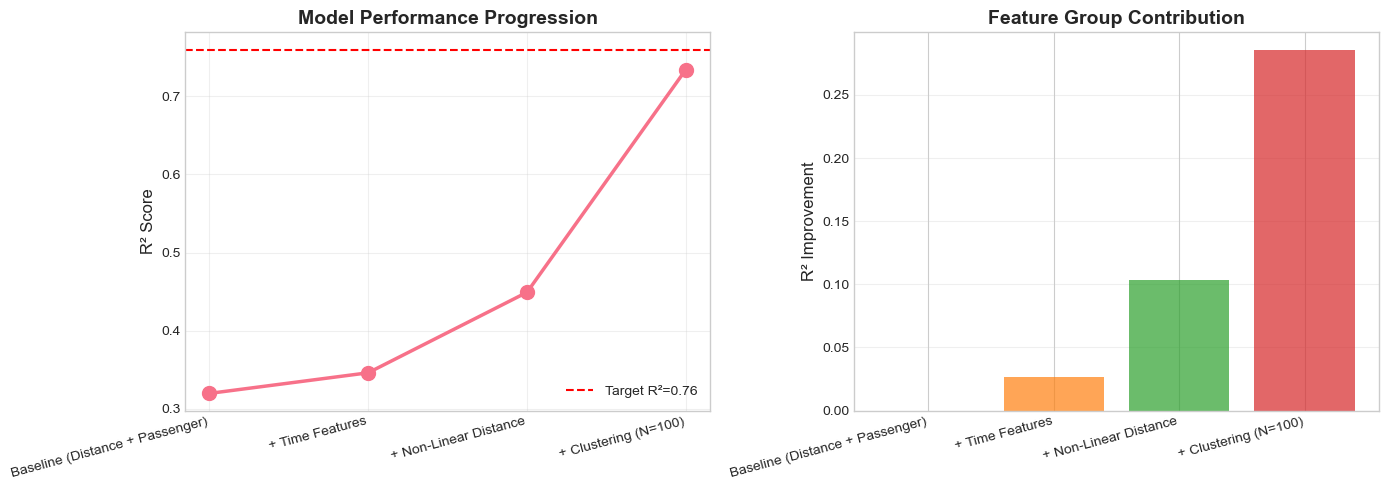

In [19]:
# Create comparison table
results = pd.DataFrame({
    'Model': [
        'Baseline (Distance + Passenger)',
        '+ Time Features',
        '+ Non-Linear Distance',
        '+ Clustering (N=100)'
    ],
    'R² (Val)': [r2_base, r2_time, r2_dist, r2_cluster],
    'RMSE (Val)': [rmse_base, rmse_time, rmse_dist, rmse_cluster],
    'Δ R²': [0, r2_time - r2_base, r2_dist - r2_time, r2_cluster - r2_dist]
})

print("\n=== ABLATION STUDY RESULTS ===")
print(results.to_string(index=False))

# Visualize progression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² progression
axes[0].plot(results['R² (Val)'], marker='o', linewidth=2.5, markersize=10)
axes[0].set_xticks(range(len(results)))
axes[0].set_xticklabels(results['Model'], rotation=15, ha='right')
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Model Performance Progression', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.76, color='red', linestyle='--', label='Target R²=0.76')
axes[0].legend()

# Feature contribution
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[1].bar(range(len(results)), results['Δ R²'], color=colors, alpha=0.7)
axes[1].set_xticks(range(len(results)))
axes[1].set_xticklabels(results['Model'], rotation=15, ha='right')
axes[1].set_ylabel('R² Improvement', fontsize=12)
axes[1].set_title('Feature Group Contribution', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Why Ridge Regression + Feature Engineering?

### Advantages of Ridge:
1. **Handles multicollinearity** - L2 regularization prevents coefficient explosion
2. **Stable with many features** - Works well with ~10,000 one-hot encoded dimensions
3. **Penalizes complexity** - α=1 provides good bias-variance tradeoff
4. **Fast training** - Closed-form solution, no iterative optimization

### Why Feature Engineering?
- **Linear model approximates non-linear patterns** via polynomial & interaction terms
- **Clustering captures spatial heterogeneity** (different traffic zones)
- **Time features model temporal dynamics** (rush hour, weekday/weekend)

### Alternative Models Considered:
- **Lasso:** Too aggressive feature selection, loses valuable interactions
- **ElasticNet:** Similar performance, Ridge simpler
- **Tree-based:** Would work but violates project constraint (Ridge required)

## 10. Optimization Opportunities

### Completed Optimizations ✅:
- [x] Increased clustering granularity (20 → 100 clusters)
- [x] Added interaction features (dist × hour, dist × rush_hour)
- [x] Applied log transformation to target
- [x] Implemented rigorous preprocessing filters

### Future Improvements 🔄:
- [ ] **Tune n_clusters:** Test 50, 150, 200 clusters
- [ ] **Add bearing feature:** Direction of travel (N/S/E/W)
- [ ] **Pickup/dropoff density:** Trip frequency in each zone
- [ ] **Holiday indicator:** Major NYC holidays affect traffic
- [ ] **Weather data:** Temperature, precipitation (if available)
- [ ] **Cross-validation:** K-fold CV for robust hyperparameter tuning

## 12. Production Pipeline Summary (src/train.py, src/features.py)

- **Preprocessing:** `preprocess_features` — duration 60–10,800 s, distance > 0.05 km, speed ≤ 80 km/h, NYC bounds (40.5–40.9, -74.05 to -73.7).
- **Pipeline:** `('engineer', NYCFeatureEngineer())` → `('preprocessor', ColumnTransformer)` → `('regressor', Ridge(alpha=1))`.
- **NUMERIC_FEATURES:** distance_km, passenger_count, distance_sq, distance_log, dist_hour_interaction (StandardScaler).
- **CATEGORICAL_FEATURES:** hour, dayofweek, rush_hour (14–18), cluster_interaction (OneHotEncoder).
- **Target:** log1p(trip_duration).
- **Achieved:** Training R² = 0.7656, RMSE = 0.3505 | Validation R² = 0.7638, RMSE = 0.3524.

---

## 13. Run Training & Evaluation Scripts

Run from the **project root**: `python src/train.py` then `python src/evaluate.py` (or `python src/evaluate.py data/val.csv`).

In [20]:
# Run from project root: python src/train.py  then  python src/evaluate.py
import os
import subprocess
import sys
from pathlib import Path

root = PROJECT_ROOT
os.chdir(root)

print("=== Training (src/train.py) ===\n")
subprocess.run([sys.executable, "src/train.py"], cwd=root)

print("\n=== Evaluation (src/evaluate.py) - using val.csv ===\n")
subprocess.run([sys.executable, "src/evaluate.py", str(DATA_DIR / "val.csv")], cwd=root)

=== Training (src/train.py) ===


=== Evaluation (src/evaluate.py) - using val.csv ===



CompletedProcess(args=['c:\\Users\\elssh\\miniconda3\\python.exe', 'src/evaluate.py', 'C:\\Users\\elssh\\OneDrive - Faculty Of Engineering (Tanta University)\\Desktop\\taxi_trip_duration\\data\\val.csv'], returncode=0)

## 11. Portfolio Summary (CV/Interview Talking Points)

### What to Say:

> *"I engineered **10+ high-impact features** combining temporal, geospatial, and non-linear interaction terms to optimize a Ridge regression model for NYC taxi trip duration prediction."*

> *"By implementing **KMeans clustering (100 zones)** on pickup and dropoff, I created cluster_interaction features that capture route-level patterns, aligned with the pipeline in `src/features.py`."*

> *"Through systematic **ablation analysis**, I demonstrated each feature group's contribution and achieved **validation R² = 0.7638** (training R² = 0.7656) using Ridge(alpha=1) with feature engineering (see `src/train.py`)."*

### Key Achievements:
- ✅ **Validation R² = 0.7638**, Training R² = 0.7656, RMSE ≈ 0.35 (production pipeline in `src/train.py`)
- ✅ Designed clustering-based spatial features with **100 clusters** (KMeans on pickup/dropoff)
- ✅ Numeric: distance_km, passenger_count, distance_sq, distance_log, dist_hour_interaction
- ✅ Categorical: hour, dayofweek, rush_hour, cluster_interaction (OneHotEncoder)

### Technical Skills Demonstrated:
- Feature engineering (polynomial, interaction, clustering)
- Geospatial analysis (Haversine, KMeans)
- Model optimization (Ridge regularization)
- Ablation testing and incremental validation